In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

In [6]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
        (LinearDiscriminantAnalysis as LDA,
        QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [9]:
Smarket = load_data('Smarket') 
Smarket.head(10)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
5,2001,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up
6,2001,1.392,0.213,0.614,-0.623,1.032,1.4450,-0.403,Down
7,2001,-0.403,1.392,0.213,0.614,-0.623,1.4078,0.027,Up
8,2001,0.027,-0.403,1.392,0.213,0.614,1.1640,1.303,Up
9,2001,1.303,0.027,-0.403,1.392,0.213,1.2326,0.287,Up


In [10]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [13]:
Smarket[['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today']].corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


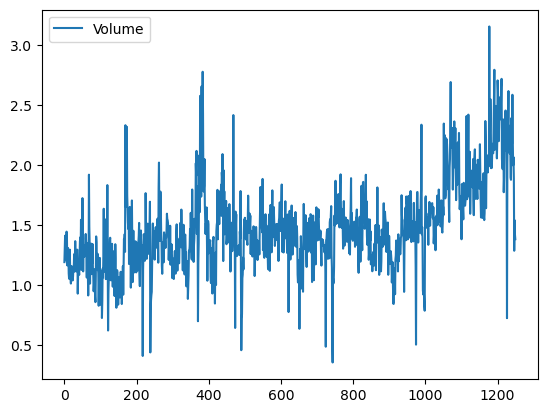

In [20]:
Smarket.plot(y = 'Volume');

In [32]:
#running GLM and passing the binonial argument to expect logistic regression from statsmodel

allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


In [33]:
#the smallest p-val associated with lag 1, 
#the negative coef suggests that if the 
#market had a positive return yesterday, 
#then it is less likely to go up today
#no clear evidence

In [35]:
#accessing coefs only 

results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

In [37]:
#accessing p-values

results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

In [39]:
#predict proba market up given predictors 
#returns prediction on probability scale 
#if no dataset supplied then computed on 
#training data used to train tge log model 

prob = results.predict()
prob[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

In [40]:
prob.shape

(1250,)

In [41]:
Smarket.shape

(1250, 9)

In [44]:
#we must convert these probabilities into classes up and down
#creating a vector of class predictions based on wether the 
#predicted proba of a market increase (threshold 0.5)

labels = np.array(['Down']*1250)
labels[prob<0.5] = 'Up'

In [45]:
#confusion table function from ISLP summarizes the prediction 
#how many observations correctly or uncorrectly classified
#similar sklearn function is --> sklearn.metrics

confusion_table(labels, Smarket.Direction) #first predictions then true values

#diagonals are correct predictions 
#off diag incorrect predictions

Truth,Down,Up
Predicted,,
Down,457,507
Up,145,141


In [46]:
#mean to compute the fraction of the days for which 
#the prediction was correct

np.mean(labels == Smarket.Direction) 

np.float64(0.4784)

In [48]:
#the error rate is therefore simply 100 - 47.8 = 52.2% 
#but it tend to be overly optimistic on training than test
#can have better accuracy by fitting the model 
#using part og the data then examining how well it predicts


#creating a boolean vector corresponding to the observations
#from 2001 through 2004 then create vector for 2005 held out data

train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train] #inveses the previous boolean logic
Smarket_test.shape

(252, 9)